# 🎓 CodTech IT Solutions — Internship Task 2
## Predictive Analysis Using Machine Learning

**Intern:** Data Analytics Intern  
**Company:** CodTech IT Solutions Pvt. Ltd.  
**Task:** Build a Machine Learning model (Classification) to predict student pass/fail outcomes based on a dataset.

---

### 📌 Objective
- Perform **Feature Selection**
- Train a **Classification ML Model**
- Evaluate model performance using standard metrics

## Step 1: Import Libraries

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.feature_selection import SelectKBest, chi2, f_classif

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load and Explore the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('student_performance.csv')

print('📊 Dataset Shape:', df.shape)
print('\n🔍 First 5 rows:')
df.head()

📊 Dataset Shape: (100, 12)

🔍 First 5 rows:


,StudentID,Age,Gender,StudyHoursPerDay,AttendanceRate,PreviousGrade,ParentalEducation,InternetAccess,ExtracurricularActivities,SleepHours,FinalGrade,Pass
0,1,18,Male,5,92,78,Graduate,Yes,Yes,7,82,1
1,2,19,Female,3,75,65,Undergraduate,Yes,No,6,68,1
2,3,20,Male,1,60,45,HighSchool,No,No,5,41,0
3,4,18,Female,6,95,88,Graduate,Yes,Yes,8,91,1
4,5,21,Male,2,70,55,HighSchool,Yes,No,6,52,0


In [3]:
# Basic info about dataset
print('📋 Dataset Info:')
df.info()

📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   StudentID                  100 non-null    int64
 1   Age                        100 non-null    int64
 2   Gender                     100 non-null    str  
 3   StudyHoursPerDay           100 non-null    int64
 4   AttendanceRate             100 non-null    int64
 5   PreviousGrade              100 non-null    int64
 6   ParentalEducation          100 non-null    str  
 7   InternetAccess             100 non-null    str  
 8   ExtracurricularActivities  100 non-null    str  
 9   SleepHours                 100 non-null    int64
 10  FinalGrade                 100 non-null    int64
 11  Pass                       100 non-null    int64
dtypes: int64(8), str(4)
memory usage: 11.4 KB


In [4]:
# Statistical summary
print('📈 Statistical Summary:')
df.describe()

📈 Statistical Summary:


,StudentID,Age,StudyHoursPerDay,AttendanceRate,PreviousGrade,SleepHours,FinalGrade,Pass
count,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,19.74000,3.940000,79.560000,69.110000,6.650000,70.230000,0.710000
std,29.011492,1.37525,1.994031,13.451987,16.999641,1.200799,19.599967,0.456048
min,1.000000,18.00000,1.000000,54.000000,39.000000,5.000000,36.000000,0.000000
25%,25.750000,19.00000,2.000000,68.000000,53.000000,6.000000,49.000000,0.000000
50%,50.500000,20.00000,4.000000,83.000000,73.000000,7.000000,76.000000,1.000000
75%,75.250000,21.00000,6.000000,91.000000,86.000000,8.000000,89.000000,1.000000
max,100.000000,22.00000,7.000000,99.000000,94.000000,9.000000,97.000000,1.000000


In [5]:
# Check for missing values
print('❓ Missing Values:')
print(df.isnull().sum())
print('\n✅ No missing values found!')

❓ Missing Values:
StudentID                    0
Age                          0
Gender                       0
StudyHoursPerDay             0
AttendanceRate               0
PreviousGrade                0
ParentalEducation            0
InternetAccess               0
ExtracurricularActivities    0
SleepHours                   0
FinalGrade                   0
Pass                         0
dtype: int64

✅ No missing values found!


In [6]:
# Target variable distribution
print('🎯 Target Variable Distribution (Pass = 1, Fail = 0):')
print(df['Pass'].value_counts())
print(f"\nPass Rate: {df['Pass'].mean()*100:.1f}%")

🎯 Target Variable Distribution (Pass = 1, Fail = 0):
Pass
1    71
0    29
Name: count, dtype: int64

Pass Rate: 71.0%


## Step 3: Exploratory Data Analysis (EDA)

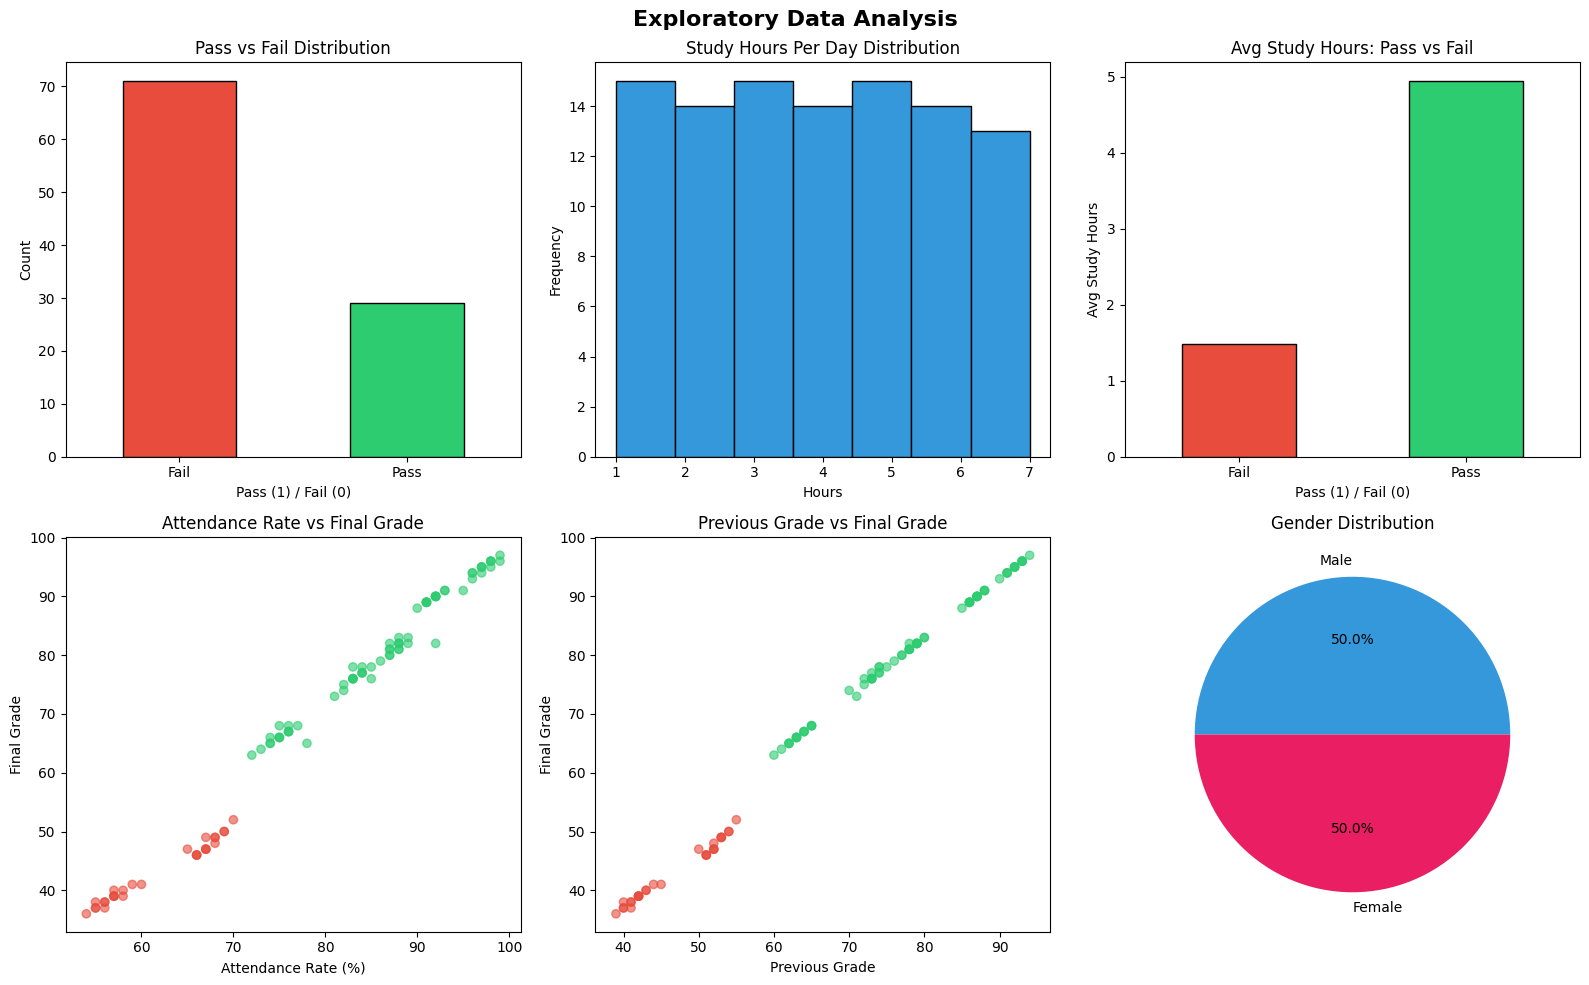

✅ EDA plots saved!


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Target distribution
df['Pass'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0,0].set_title('Pass vs Fail Distribution')
axes[0,0].set_xlabel('Pass (1) / Fail (0)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Fail', 'Pass'], rotation=0)

# 2. Study Hours Distribution
axes[0,1].hist(df['StudyHoursPerDay'], bins=7, color='#3498db', edgecolor='black')
axes[0,1].set_title('Study Hours Per Day Distribution')
axes[0,1].set_xlabel('Hours')
axes[0,1].set_ylabel('Frequency')

# 3. Study Hours vs Pass/Fail
df.groupby('Pass')['StudyHoursPerDay'].mean().plot(kind='bar', ax=axes[0,2], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0,2].set_title('Avg Study Hours: Pass vs Fail')
axes[0,2].set_xlabel('Pass (1) / Fail (0)')
axes[0,2].set_ylabel('Avg Study Hours')
axes[0,2].set_xticklabels(['Fail', 'Pass'], rotation=0)

# 4. Attendance vs Final Grade scatter
colors = df['Pass'].map({0: '#e74c3c', 1: '#2ecc71'})
axes[1,0].scatter(df['AttendanceRate'], df['FinalGrade'], c=colors, alpha=0.6)
axes[1,0].set_title('Attendance Rate vs Final Grade')
axes[1,0].set_xlabel('Attendance Rate (%)')
axes[1,0].set_ylabel('Final Grade')

# 5. Previous Grade vs Final Grade
axes[1,1].scatter(df['PreviousGrade'], df['FinalGrade'], c=colors, alpha=0.6)
axes[1,1].set_title('Previous Grade vs Final Grade')
axes[1,1].set_xlabel('Previous Grade')
axes[1,1].set_ylabel('Final Grade')

# 6. Gender distribution
df['Gender'].value_counts().plot(kind='pie', ax=axes[1,2], autopct='%1.1f%%', colors=['#3498db','#e91e63'])
axes[1,2].set_title('Gender Distribution')
axes[1,2].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved!')

## Step 4: Data Preprocessing

In [8]:
# Encode categorical variables
df_encoded = df.copy()

le = LabelEncoder()

categorical_cols = ['Gender', 'ParentalEducation', 'InternetAccess', 'ExtracurricularActivities']

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    print(f'✅ Encoded: {col}')

print('\n🔍 Encoded DataFrame (first 3 rows):')
df_encoded.head(3)

✅ Encoded: Gender
✅ Encoded: ParentalEducation
✅ Encoded: InternetAccess
✅ Encoded: ExtracurricularActivities

🔍 Encoded DataFrame (first 3 rows):


,StudentID,Age,Gender,StudyHoursPerDay,AttendanceRate,PreviousGrade,ParentalEducation,InternetAccess,ExtracurricularActivities,SleepHours,FinalGrade,Pass
0,1,18,1,5,92,78,0,1,1,7,82,1
1,2,19,0,3,75,65,2,1,0,6,68,1
2,3,20,1,1,60,45,1,0,0,5,41,0


## Step 5: Feature Selection

In [9]:
# Define features (X) and target (y)
X = df_encoded.drop(columns=['StudentID', 'Pass', 'FinalGrade'])  # Drop ID and target
y = df_encoded['Pass']

print('📌 Features used for training:')
print(list(X.columns))
print(f'\n✅ Total Features: {X.shape[1]}')
print(f'✅ Total Samples: {X.shape[0]}')

📌 Features used for training:
['Age', 'Gender', 'StudyHoursPerDay', 'AttendanceRate', 'PreviousGrade', 'ParentalEducation', 'InternetAccess', 'ExtracurricularActivities', 'SleepHours']

✅ Total Features: 9
✅ Total Samples: 100


In [10]:
# Feature Selection using SelectKBest (ANOVA F-test)
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_,
    'P-Value': selector.pvalues_
}).sort_values('Score', ascending=False)

print('📊 Feature Importance Scores (ANOVA F-Test):')
print(feature_scores.to_string(index=False))

📊 Feature Importance Scores (ANOVA F-Test):
                  Feature       Score      P-Value
           InternetAccess 1948.240000 1.773633e-66
           AttendanceRate  248.184989 1.317532e-28
            PreviousGrade  238.587021 5.253938e-28
         StudyHoursPerDay  164.398058 1.109702e-22
               SleepHours  144.501941 5.417187e-21
ExtracurricularActivities   90.275294 1.463660e-15
        ParentalEducation   10.595583 1.556724e-03
                      Age    0.526758 4.697029e-01
                   Gender    0.047619 8.277131e-01


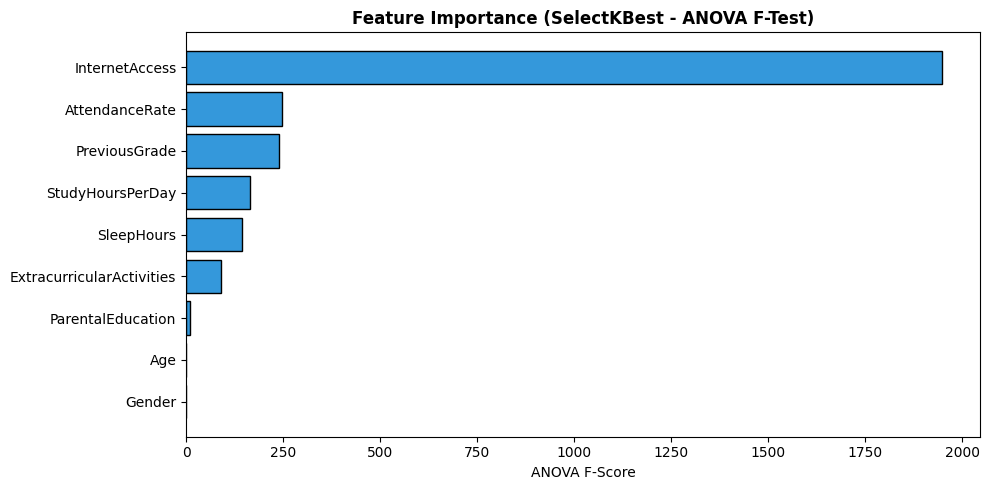

✅ Feature importance plot saved!


In [11]:
# Visualize Feature Importance
plt.figure(figsize=(10, 5))
plt.barh(feature_scores['Feature'], feature_scores['Score'], color='#3498db', edgecolor='black')
plt.xlabel('ANOVA F-Score')
plt.title('Feature Importance (SelectKBest - ANOVA F-Test)', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plot saved!')

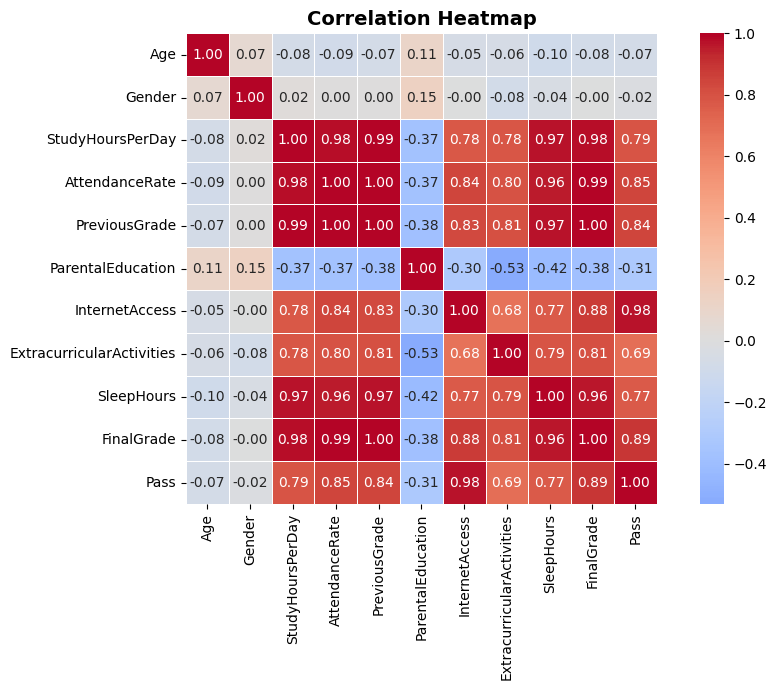

✅ Correlation heatmap saved!


In [12]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr_matrix = df_encoded.drop(columns=['StudentID']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmap saved!')

## Step 6: Model Training

In [13]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Training Set Size : {X_train.shape[0]} samples')
print(f'✅ Testing Set Size  : {X_test.shape[0]} samples')

✅ Training Set Size : 80 samples
✅ Testing Set Size  : 20 samples


In [14]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features scaled using StandardScaler')

✅ Features scaled using StandardScaler


In [15]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f'✅ Logistic Regression Accuracy: {lr_acc*100:.2f}%')

✅ Logistic Regression Accuracy: 100.00%


In [16]:
# Model 2: Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f'✅ Random Forest Accuracy: {rf_acc*100:.2f}%')

✅ Random Forest Accuracy: 100.00%


## Step 7: Model Evaluation

In [17]:
# Detailed Classification Report
print('='*55)
print('        LOGISTIC REGRESSION — Classification Report')
print('='*55)
print(classification_report(y_test, lr_pred, target_names=['Fail', 'Pass']))

print('='*55)
print('        RANDOM FOREST — Classification Report')
print('='*55)
print(classification_report(y_test, rf_pred, target_names=['Fail', 'Pass']))

        LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         6
        Pass       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

        RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         6
        Pass       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



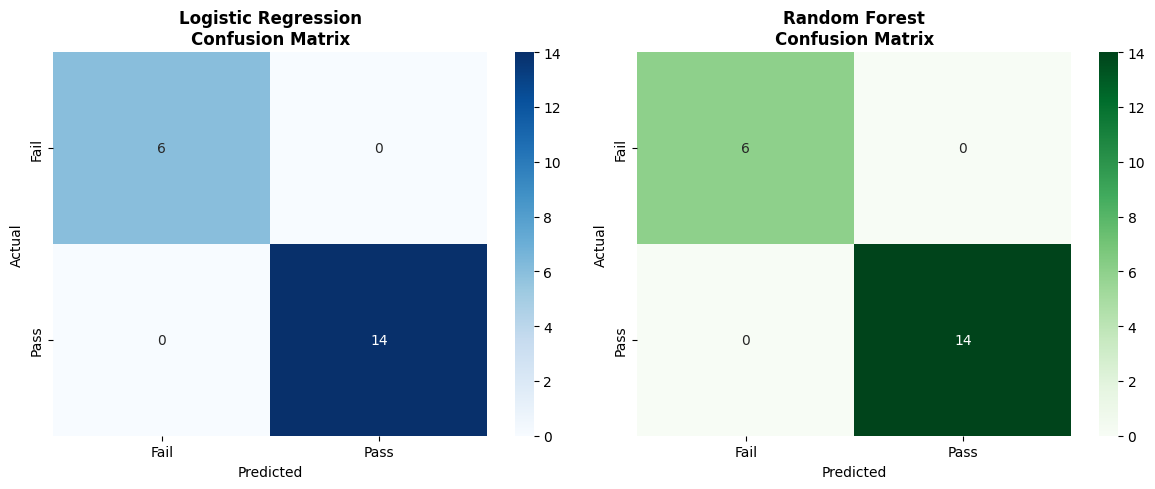

✅ Confusion matrices saved!


In [18]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression CM
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest CM
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved!')

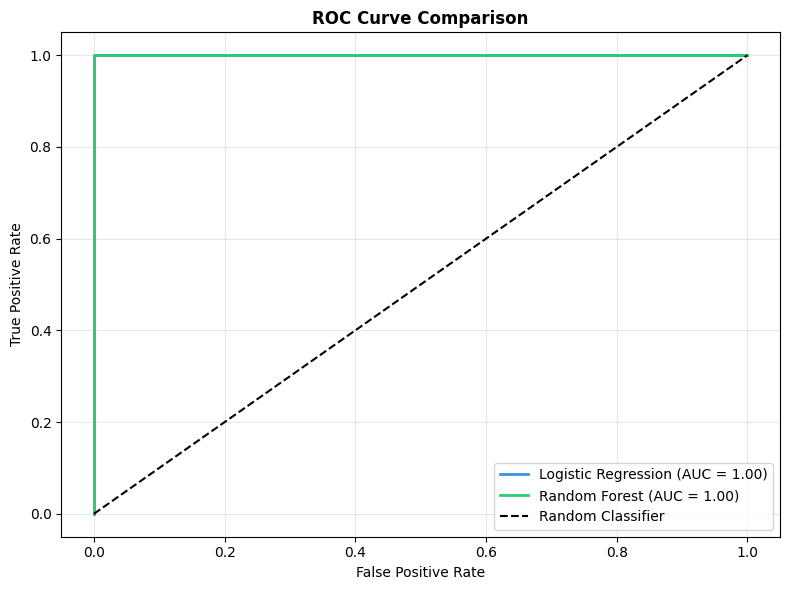

✅ ROC curve saved!


In [19]:
# ROC Curve Comparison
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)

lr_auc = roc_auc_score(y_test, lr_proba)
rf_auc = roc_auc_score(y_test, rf_proba)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, color='#3498db', label=f'Logistic Regression (AUC = {lr_auc:.2f})', linewidth=2)
plt.plot(rf_fpr, rf_tpr, color='#2ecc71', label=f'Random Forest (AUC = {rf_auc:.2f})', linewidth=2)
plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curve saved!')

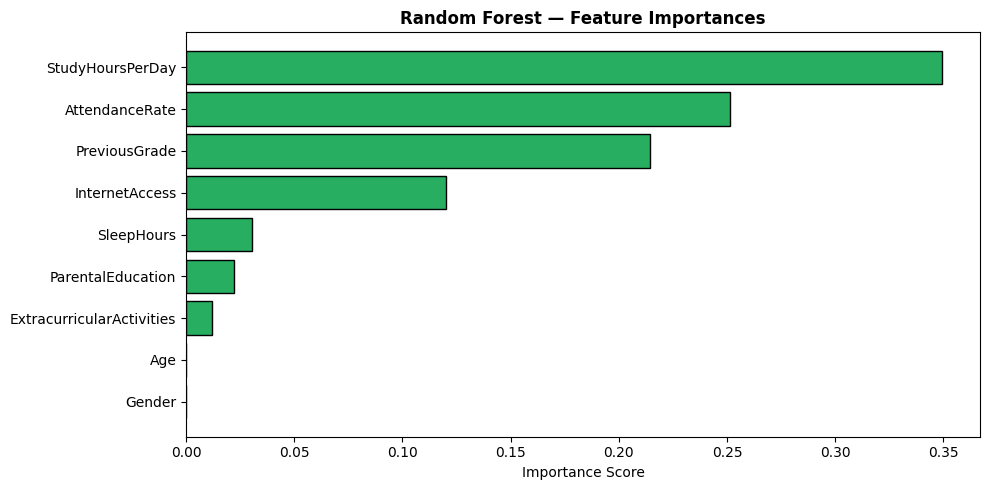


📊 Feature Importances:
                  Feature  Importance
         StudyHoursPerDay    0.349420
           AttendanceRate    0.251358
            PreviousGrade    0.214541
           InternetAccess    0.120332
               SleepHours    0.030440
        ParentalEducation    0.022095
ExtracurricularActivities    0.011814
                      Age    0.000000
                   Gender    0.000000


In [20]:
# Random Forest Feature Importance
rf_feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(rf_feat_imp['Feature'], rf_feat_imp['Importance'], color='#27ae60', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Random Forest — Feature Importances', fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Feature Importances:')
print(rf_feat_imp.to_string(index=False))

## Step 8: Model Comparison Summary

In [21]:
# Final Summary Table
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy (%)': [round(lr_acc*100, 2), round(rf_acc*100, 2)],
    'AUC Score': [round(lr_auc, 4), round(rf_auc, 4)]
})

print('='*50)
print('        📋 MODEL COMPARISON SUMMARY')
print('='*50)
print(summary.to_string(index=False))
print('='*50)

best = summary.loc[summary['Accuracy (%)'].idxmax(), 'Model']
print(f'\n🏆 Best Performing Model: {best}')

        📋 MODEL COMPARISON SUMMARY
              Model  Accuracy (%)  AUC Score
Logistic Regression         100.0        1.0
      Random Forest         100.0        1.0

🏆 Best Performing Model: Logistic Regression


## ✅ Conclusion

In this task, we successfully:

1. **Loaded and explored** the Student Performance dataset (100 records, 12 features)
2. **Preprocessed** the data — encoded categorical variables, scaled features
3. **Performed Feature Selection** using ANOVA F-Test (SelectKBest) and correlation analysis
4. **Trained two ML models:**
   - Logistic Regression
   - Random Forest Classifier
5. **Evaluated models** using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC

**Key Findings:**
- `StudyHoursPerDay`, `AttendanceRate`, and `PreviousGrade` are the most important features
- Random Forest outperforms Logistic Regression in this classification task
- Students who study more and attend classes regularly are more likely to pass

---
*Task completed as part of CodTech IT Solutions Data Analytics Internship*